In [1]:
import numpy as np
import pandas as pd

In [24]:
df_tabular['aki_boolean'].astype(int).sum() /len(df_tabular['aki_boolean'])

0.05955042755466043

In [28]:
df_combined['aki_boolean'].astype(int).sum() /len(df_combined['aki_boolean'])

0.0635457792818199

In [26]:
df_combined.shape

(47871, 521)

In [25]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

tabular_csv = '/home/server/Projects/data/AKI/tabular_combined.csv'
df_tabular = pd.read_csv(tabular_csv)

file = '/home/server/Projects/data/AKI/time_series_cleaned.csv'
df_time = pd.read_csv(file)

# drops operations that are missing over half of all features
feature_mask = df_time.drop(columns=['op_id', 'chart_time']).notna().astype(int)
df_time['presence'] = feature_mask.sum(axis=1) / 24
# drops about 1/6 data
df_time = df_time[df_time['presence'] > (1/2)].drop(columns=['presence']) 
mask_flag_value = 0
df_time = df_time.fillna(mask_flag_value)
bool_cols = df_tabular.select_dtypes(include='bool').columns
df_tabular[bool_cols] = df_tabular[bool_cols].astype(float)


# pivot and pad, re-df
padded_tensors = []
pad_length = 200
op_ids = []
sequence_lengths = []
for op_id, group in tqdm(df_time.groupby("op_id"), desc="grouping by op_ids"):
    mat = torch.tensor(group.drop(columns=['op_id', 'chart_time']).values)
    if mat.shape[0] < 200: # throws away about 4% of longest operations bc they would extend max pad length from 200 to like 600
        padded_tensors.append(torch.nn.functional.pad(mat, pad=(0, 0, 0, pad_length - mat.shape[0]), value=0))
        op_ids.append(op_id)
        sequence_lengths.append(mat.shape[0])
df_time = pd.DataFrame({
    'op_id': op_ids,
    'time_tensors': padded_tensors,
    'seq_len': sequence_lengths
    })
df_combined = df_time.merge(df_tabular, on='op_id', how='inner')

grouping by op_ids: 100%|██████████| 48956/48956 [00:17<00:00, 2860.96it/s]


[    25  15154  77757  94038 124539 236981 889192 696137 895716 110741]
[0.04166667 0.1375     0.23333333 0.32916667 0.425      0.52083333
 0.61666667 0.7125     0.80833333 0.90416667 1.        ]


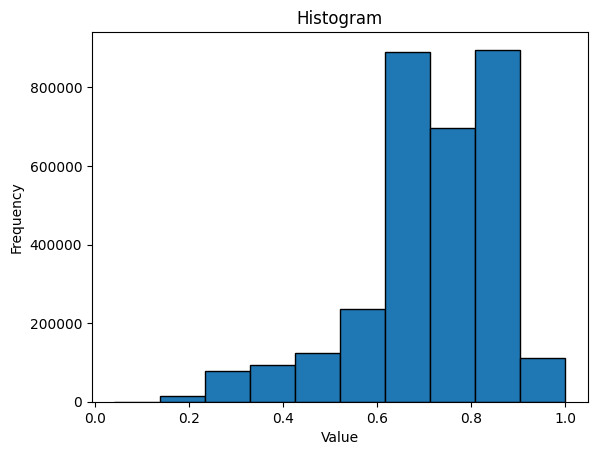

In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = df_time['presence'].values

hist, bins = np.histogram(data, bins=10)  # Compute histogram
print(hist)  # Counts in each bin
print(bins)  # Bin edges

plt.hist(data, bins=10, edgecolor='black')  # Plot histogram
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

In [4]:
# drops about 1/6 data
df_time = df_time[df_time['presence'] > (1/2)].drop(columns=['presence']) 
mask_flag_value = 0
df_time = df_time.fillna(mask_flag_value)
bool_cols = df_tabular.select_dtypes(include='bool').columns
df_tabular[bool_cols] = df_tabular[bool_cols].astype(float)

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import os

def performance_dict(y_binary_test, y_pred, y_prob, bool_print=False, plot=False, copy_print=False):
    rtn = {}
    report = classification_report(y_binary_test, y_pred, output_dict=True)
    rtn['Precision'] = report['True']['precision']
    rtn['Sensitivity'] = report['True']['recall']
    rtn["Accuracy"] = accuracy_score(y_binary_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    rtn["rc_auc"] = auc(fpr, tpr)
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    rtn["pr_auc"] = auc(rec, prec)
    rtn['Specificity'] = report['False']['recall']
    rtn['Negative Predictive Value'] = report['False']['precision']
    rtn['F1 Score'] = report['True']['f1-score']
    return rtn

def df_to_tensors(df):
    remove_cols = [col for col in df.columns if '_isna' in col]
    remove_cols += ['op_id', 'time_tensors', 'seq_len', 'aki', 'aki_boolean', 'aki_positive']
    X_tab = torch.tensor(df.drop(columns=remove_cols).values).float()
    X_time = torch.stack(df['time_tensors'].tolist()).float()
    y = torch.tensor(df['aki'].values).unsqueeze(1).float()
    sequence_lengths = df['seq_len'].tolist()
    return X_tab, X_time, y, sequence_lengths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
df_train_file = '/home/server/Projects/data/AKI/lstm/df_train.pkl'
df_test_file = '/home/server/Projects/data/AKI/lstm/df_test.pkl'
df_train = pd.read_pickle(df_train_file)
df_test = pd.read_pickle(df_test_file)

In [3]:
def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations





In [51]:
def steep_sigmoid(x):
    return 2 * (- 0.5 + (1 / (1 + np.exp(-4 * x))))

In [53]:
X_tab_train, X_time_train, y_train, seq_len_train = df_to_tensors(df_train)
X_tab_train = X_tab_train.to(device)
y_train = steep_sigmoid((y_train - 0.3).float()).to(device)

In [54]:
X_tab_test, X_time_test, y_test, seq_len_test = df_to_tensors(df_test)
X_tab_test = X_tab_test.to(device)
y_test = steep_sigmoid((y_test - 0.3).float()).to(device)

In [44]:
num_epochs = 500 #1000 epochs
learning_rate = 0.001 #0.001 lr

tabular_input_size = X_tab_train.shape[1] #271 without isna
input_size = 24 #number of features
hidden_size = 2 * 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

batch_size = 10000
num_train_samples = X_tab_train.shape[0]
num_batches = int(np.ceil(num_train_samples / batch_size))

hidden_layer_sizes = [8, 8, 4, 32, 2]

set_seed(42)

def build_mlp(hidden_layer_sizes):
        mlp = nn.Sequential()
        prev = tabular_input_size
        for dim in hidden_layer_sizes:
                mlp.append(nn.Linear(prev, dim))
                mlp.append(nn.ReLU())
                prev = dim
        mlp.append(nn.Linear(prev, 1))
        # mlp.append(nn.Sigmoid())
        mlp = mlp.to(device)
        return mlp

# lstm1 = HybridLSTM(num_classes, input_size, hidden_size, num_layers, tabular_input_size).to(device)

In [55]:

mlp = build_mlp(hidden_layer_sizes)
criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
    batch_loss = 0
    for i in range(num_batches):
        beginning_idx = i * batch_size
        ending_idx = min(num_train_samples, (i + 1) * batch_size)
        X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
        y = y_train[beginning_idx: ending_idx]#.to(device)
        outputs = mlp.forward(X_tab) #forward pass
    
        optimizer.zero_grad() #calculate the gradient, manually setting to 0
        loss = criterion(outputs, y)
        loss.backward() #calculates the loss of the loss function
        optimizer.step() #improve from loss, i.e backprop
        batch_loss += loss.item()

    if epoch % 100 == 99:
        mlp.eval()
        with torch.no_grad():
            outputs = mlp(X_tab_test)
            leg_y_test = (y_test > 0).T.tolist()[0]
            leg_y_pred = (outputs > 0).T.tolist()[0]
            leg_y_prob = nn.functional.sigmoid(outputs - 0).T.tolist()[0]
            dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
            print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
            print(dic)
        mlp.train()


 21%|██        | 104/500 [00:05<00:18, 21.57it/s]

Epoch: 99, loss: 0.10228
{'Precision': 0.20738974970202623, 'Sensitivity': 0.5780730897009967, 'Accuracy': 0.8345519114267809, 'rc_auc': 0.7811482160075717, 'pr_auc': 0.34662669639412214, 'Specificity': 0.8517610343290236, 'Negative Predictive Value': 0.9678318135764944, 'F1 Score': 0.30526315789473685}


 41%|████      | 203/500 [00:10<00:16, 17.59it/s]

Epoch: 199, loss: 0.09475
{'Precision': 0.2019704433497537, 'Sensitivity': 0.5448504983388704, 'Accuracy': 0.8360142051389179, 'rc_auc': 0.77333357525739, 'pr_auc': 0.35325855641097137, 'Specificity': 0.8555506018724922, 'Negative Predictive Value': 0.9655345911949685, 'F1 Score': 0.29469901168014373}


 61%|██████    | 305/500 [00:16<00:08, 22.40it/s]

Epoch: 299, loss: 0.09200
{'Precision': 0.20351758793969849, 'Sensitivity': 0.5382059800664452, 'Accuracy': 0.8385209943597243, 'rc_auc': 0.766818659158134, 'pr_auc': 0.344654863270109, 'Specificity': 0.8586714222024074, 'Negative Predictive Value': 0.9651716361814082, 'F1 Score': 0.29535095715587967}


 81%|████████  | 403/500 [00:20<00:05, 17.25it/s]

Epoch: 399, loss: 0.09069
{'Precision': 0.20382165605095542, 'Sensitivity': 0.53156146179402, 'Accuracy': 0.8399832880718613, 'rc_auc': 0.7595031719206153, 'pr_auc': 0.3435991882073059, 'Specificity': 0.8606776638430673, 'Negative Predictive Value': 0.9647676161919041, 'F1 Score': 0.2946593001841621}


100%|██████████| 500/500 [00:26<00:00, 18.96it/s]

Epoch: 499, loss: 0.08953
{'Precision': 0.20101137800252844, 'Sensitivity': 0.5282392026578073, 'Accuracy': 0.8383120952579904, 'rc_auc': 0.7528197729962393, 'pr_auc': 0.3398880476202806, 'Specificity': 0.8591172536781096, 'Negative Predictive Value': 0.9644644644644644, 'F1 Score': 0.29120879120879123}


In [ ]:

mlp = build_mlp(hidden_layer_sizes)
criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs * 0.5)):
    batch_loss = 0
    for i in range(num_batches):
        beginning_idx = i * batch_size
        ending_idx = min(num_train_samples, (i + 1) * batch_size)
        X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
        y = y_train[beginning_idx: ending_idx]#.to(device)
        outputs = mlp.forward(X_tab) #forward pass
    
        optimizer.zero_grad() #calculate the gradient, manually setting to 0
        loss = criterion(outputs, y)
        loss.backward() #calculates the loss of the loss function
        optimizer.step() #improve from loss, i.e backprop
        batch_loss += loss.item()

    if epoch % 100 == 99:
        mlp.eval()
        with torch.no_grad():
            outputs = mlp(X_tab_test)
            leg_y_test = (y_test > 0).T.tolist()[0]
            leg_y_pred = (outputs > 0).T.tolist()[0]
            leg_y_prob = nn.functional.sigmoid(outputs - 0).T.tolist()[0]
            dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
            print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
            print(dic)
        mlp.train()


  0%|          | 2/2000 [00:00<01:49, 18.25it/s]

  5%|▌         | 103/2000 [00:05<01:47, 17.59it/s]

Epoch: 99, loss: 0.03647
{'Precision': 0.20040281973816718, 'Sensitivity': 0.6611295681063123, 'Accuracy': 0.8128264048464592, 'rc_auc': 0.7825231099189358, 'pr_auc': 0.22152911702243372, 'Specificity': 0.8230049041462327, 'Negative Predictive Value': 0.9731154454401687, 'F1 Score': 0.3075734157650695}


 10%|█         | 204/2000 [00:11<01:41, 17.69it/s]

Epoch: 199, loss: 0.03281
{'Precision': 0.19438444924406048, 'Sensitivity': 0.5980066445182725, 'Accuracy': 0.8188844787967412, 'rc_auc': 0.7597260876584664, 'pr_auc': 0.2012085341085534, 'Specificity': 0.8337048595630852, 'Negative Predictive Value': 0.9686609686609686, 'F1 Score': 0.293398533007335}


...

Epoch: 1799, loss: 0.03034
{'Precision': 0.21712907117008443, 'Sensitivity': 0.5980066445182725, 'Accuracy': 0.8391476916649259, 'rc_auc': 0.7522987722600989, 'pr_auc': 0.1977830717288657, 'Specificity': 0.855327686134641, 'Negative Predictive Value': 0.9694290045477514, 'F1 Score': 0.3185840707964602}


 95%|█████████▌| 1903/2000 [01:42<00:05, 17.36it/s]

Epoch: 1899, loss: 0.02885
{'Precision': 0.2209737827715356, 'Sensitivity': 0.5880398671096345, 'Accuracy': 0.8437434719030709, 'rc_auc': 0.7528008881081488, 'pr_auc': 0.19661896815624266, 'Specificity': 0.8609005795809184, 'Negative Predictive Value': 0.9688911189162067, 'F1 Score': 0.32123411978221417}


100%|██████████| 2000/2000 [01:47<00:00, 18.54it/s]

Epoch: 1999, loss: 0.02913
{'Precision': 0.2218091697645601, 'Sensitivity': 0.5946843853820598, 'Accuracy': 0.8433256736996031, 'rc_auc': 0.752650919879196, 'pr_auc': 0.19523011975024923, 'Specificity': 0.8600089166295141, 'Negative Predictive Value': 0.9693467336683417, 'F1 Score': 0.3231046931407942}


In [ ]:
'Precision': 0.2010, 'Sensitivity': 0.5282, 'Accuracy': 0.8383, 
'rc_auc': 0.7528, 'pr_auc': 0.3398, 'Specificity': 0.8591, 
'Negative Predictive Value': 0.9644, 'F1 Score': 0.2912

Sigmoid labels -6
'Precision': 0.1926, 'Sensitivity': 0.5548, 'Accuracy': 0.8257, 
'rc_auc': 0.7250, 'pr_auc': 0.1591, 'Specificity': 0.8439, 
'Negative Predictive Value': 0.96581, 'F1 Score': 0.285
Sigmoid labels -7
'Precision': 0.2218, 'Sensitivity': 0.5946, 'Accuracy': 0.8433, 
'rc_auc': 0.7526, 'pr_auc': 0.19523, 'Specificity': 0.86000, 
'Negative Predictive Value': 0.969, 'F1 Score': 0.3231
Regular MLP
'Precision': 0.1556, 'Sensitivity': 0.5946, 'Accuracy': 0.7716, 
'rc_auc': 0.7638, 'pr_auc': 0.1688, 'Specificity': 0.78354, 
'Negative Predictive Value': 0.9664, 'F1 Score': 0.2467
Classify
'Precision': 0.2024, 'Sensitivity': 0.6644, 'Accuracy': 0.8142, 
'rc_auc': 0.7683, 'pr_auc': 0.22433744923549404, 'Specificity': 0.8243,
'Negative Predictive Value': 0.9734, 'F1 Score': 0.3103



In [13]:

mlp = build_mlp(hidden_layer_sizes)
criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs * 2)):
    batch_loss = 0
    for i in range(num_batches):
        beginning_idx = i * batch_size
        ending_idx = min(num_train_samples, (i + 1) * batch_size)
        X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
        y = y_train[beginning_idx: ending_idx]#.to(device)
        outputs = mlp.forward(X_tab) #forward pass
    
        optimizer.zero_grad() #calculate the gradient, manually setting to 0
        loss = criterion(outputs, y)
        loss.backward() #calculates the loss of the loss function
        optimizer.step() #improve from loss, i.e backprop
        batch_loss += loss.item()

    if epoch % 100 == 99:
        mlp.eval()
        with torch.no_grad():
            outputs = mlp(X_tab_test)
            leg_y_test = (y_test > 0.3).T.tolist()[0]
            leg_y_pred = (outputs > 0.3).T.tolist()[0]
            leg_y_prob = nn.functional.sigmoid(outputs - 0.3).T.tolist()[0]
            dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
            print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
            print(dic)
        mlp.train()

  5%|▌         | 103/2000 [00:05<01:51, 16.98it/s]

Epoch: 99, loss: 0.07704
{'Precision': 0.14843205574912893, 'Sensitivity': 0.707641196013289, 'Accuracy': 0.7263421767286401, 'rc_auc': 0.7936344596626196, 'pr_auc': 0.19717937937569113, 'Specificity': 0.7275969683459652, 'Negative Predictive Value': 0.9737470167064439, 'F1 Score': 0.24539170506912442}


 10%|█         | 203/2000 [00:11<01:44, 17.22it/s]

Epoch: 199, loss: 0.06392
{'Precision': 0.13628522139160437, 'Sensitivity': 0.7873754152823921, 'Accuracy': 0.6728640066847713, 'rc_auc': 0.7981964561581768, 'pr_auc': 0.1952745898303012, 'Specificity': 0.6651805617476594, 'Negative Predictive Value': 0.979002624671916, 'F1 Score': 0.2323529411764706}


 15%|█▌        | 303/2000 [00:16<01:36, 17.50it/s]

...

Epoch: 1799, loss: 0.04909
{'Precision': 0.1630716134598792, 'Sensitivity': 0.627906976744186, 'Accuracy': 0.7739711719239607, 'rc_auc': 0.764495077339171, 'pr_auc': 0.16569257903756662, 'Specificity': 0.7837717342844405, 'Negative Predictive Value': 0.9691289966923925, 'F1 Score': 0.2589041095890411}


 95%|█████████▌| 1903/2000 [01:43<00:05, 17.30it/s]

Epoch: 1899, loss: 0.04791
{'Precision': 0.15527950310559005, 'Sensitivity': 0.5813953488372093, 'Accuracy': 0.7748067683308961, 'rc_auc': 0.7606747755660652, 'pr_auc': 0.1678096601731711, 'Specificity': 0.7877842175657601, 'Negative Predictive Value': 0.9655737704918033, 'F1 Score': 0.24509803921568626}


100%|██████████| 2000/2000 [01:48<00:00, 18.41it/s]

Epoch: 1999, loss: 0.04880
{'Precision': 0.15565217391304348, 'Sensitivity': 0.5946843853820598, 'Accuracy': 0.7716732818048883, 'rc_auc': 0.7638892797525858, 'pr_auc': 0.1688958773823712, 'Specificity': 0.7835488185465894, 'Negative Predictive Value': 0.9664558702227111, 'F1 Score': 0.2467263955892488}


In [ ]:

mlp = build_mlp(hidden_layer_sizes)
criterion = torch.nn.BCELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs * 2)):
    batch_loss = 0
    for i in range(num_batches):
        beginning_idx = i * batch_size
        ending_idx = min(num_train_samples, (i + 1) * batch_size)
        X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
        y = y_train[beginning_idx: ending_idx]#.to(device)
        outputs = mlp.forward(X_tab) #forward pass
    
        optimizer.zero_grad() #calculate the gradient, manually setting to 0
        loss = criterion(outputs, y)
        loss.backward() #calculates the loss of the loss function
        optimizer.step() #improve from loss, i.e backprop
        batch_loss += loss.item()

    if epoch % 100 == 99:
        mlp.eval()
        with torch.no_grad():
            outputs = mlp(X_tab_test)
            leg_y_test = (y_test > 0.3).T.tolist()[0]
            leg_y_pred = (outputs > 0.3).T.tolist()[0]
            leg_y_prob = nn.functional.sigmoid(outputs - 0.3).T.tolist()[0]
            dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
            print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
            print(dic)
        mlp.train()

  5%|▌         | 103/2000 [00:05<01:57, 16.16it/s]

Epoch: 99, loss: 0.23489
{'Precision': 0.15379008746355685, 'Sensitivity': 0.7009966777408638, 'Accuracy': 0.738667223730938, 'rc_auc': 0.7783651019117431, 'pr_auc': 0.27432681353460536, 'Specificity': 0.7411948283548818, 'Negative Predictive Value': 0.9736456808199122, 'F1 Score': 0.2522414823670054}


 10%|█         | 202/2000 [00:11<01:43, 17.38it/s]

Epoch: 199, loss: 0.20371
{'Precision': 0.1647909967845659, 'Sensitivity': 0.6810631229235881, 'Accuracy': 0.762899519532066, 'rc_auc': 0.7891498541790406, 'pr_auc': 0.26355461200618785, 'Specificity': 0.7683905483727151, 'Negative Predictive Value': 0.9729043183742591, 'F1 Score': 0.26537216828478966}


 15%|█▌        | 303/2000 [00:17<01:41, 16.74it/s]

...

Epoch: 1799, loss: 0.15747
{'Precision': 0.19783464566929135, 'Sensitivity': 0.6677740863787376, 'Accuracy': 0.8088573219135158, 'rc_auc': 0.7704301162864758, 'pr_auc': 0.23156711057855875, 'Specificity': 0.8183236736513598, 'Negative Predictive Value': 0.973481835057014, 'F1 Score': 0.3052391799544419}


 95%|█████████▌| 1902/2000 [01:42<00:05, 17.05it/s]

Epoch: 1899, loss: 0.15954
{'Precision': 0.19707317073170733, 'Sensitivity': 0.6710963455149501, 'Accuracy': 0.8073950282013788, 'rc_auc': 0.7689300637050224, 'pr_auc': 0.22176363023277806, 'Specificity': 0.816540347748551, 'Negative Predictive Value': 0.9736842105263158, 'F1 Score': 0.3046757164404223}


100%|██████████| 2000/2000 [01:48<00:00, 18.50it/s]

Epoch: 1999, loss: 0.15415
{'Precision': 0.20242914979757085, 'Sensitivity': 0.6644518272425249, 'Accuracy': 0.8142886985585962, 'rc_auc': 0.7683731446523181, 'pr_auc': 0.22433744923549404, 'Specificity': 0.8243423985733392, 'Negative Predictive Value': 0.9734140563306133, 'F1 Score': 0.3103180760279286}


In [ ]:
j = 80
# for hidden_layer_sizes in [[4, 16, 8, 2], [4, 16, 8, 2], [4, 16, 8, 2], [4, 16, 8, 2],
#                            [16, 8, 4, 2], [16, 8, 4, 2], [16, 8, 4, 2], [16, 8, 4, 2],
#                            [4, 8, 4, 2], [4, 4, 4], [8, 16, 16, 16, 2], [8, 16, 16, 16, 2]
#                            ]:
for hidden_layer_sizes in[hidden_layer_sizes]:
  j += 1
  extra_string = "_".join([str(ls) for ls in hidden_layer_sizes])
  file_name = '/home/server/Projects/data/AKI/runs/dnn/hidden_grid_relusig' + str(j) + '_class_' + extra_string
  if True:
  #if hidden_layer_sizes[0] != 8 and os.path.exists(file_name):
    print(extra_string)
    writer = SummaryWriter(file_name)

    mlp = build_mlp(hidden_layer_sizes)
    criterion = torch.nn.BCELoss()    # mean-squared error for regression
    optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate) 
    for epoch in tqdm(range(num_epochs * 2)):
      batch_loss = 0
      for i in range(num_batches):
        beginning_idx = i * batch_size
        ending_idx = min(num_train_samples, (i + 1) * batch_size)
        X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
        y = y_train[beginning_idx: ending_idx]#.to(device)
        seq_len = seq_len_train[beginning_idx: ending_idx]
        outputs = mlp.forward(X_tab) #forward pass
        
        optimizer.zero_grad() #calculate the gradient, manually setting to 0
        loss = criterion(outputs, y)
        loss.backward() #calculates the loss of the loss function
        optimizer.step() #improve from loss, i.e backprop
        batch_loss += loss.item()

      if epoch % 100 == 99:
        writer.add_scalar('training loss',
                              batch_loss / num_batches,
                              epoch * num_batches + i)
        mlp.eval()
        with torch.no_grad():
          outputs = mlp(X_tab_test)
          leg_y_test = (y_test > 0.3).T.tolist()[0]
          leg_y_pred = (outputs > 0.3).T.tolist()[0]
          leg_y_prob = nn.functional.sigmoid(outputs - 0.3).T.tolist()[0]
          dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
          writer.add_scalar('Precision',
                              dic['Precision'],
                              epoch * num_batches + i)
          writer.add_scalar('Sensitivity',
                              dic['Sensitivity'],
                              epoch * num_batches + i)
          writer.add_scalar('Accuracy',
                              dic['Accuracy'],
                              epoch * num_batches + i)
          writer.add_scalar('rc_auc',
                              dic['rc_auc'],
                              epoch * num_batches + i)
          writer.add_scalar('pr_auc',
                              dic['pr_auc'],
                              epoch * num_batches + i)
          writer.add_scalar('Specificity',
                              dic['Specificity'],
                              epoch * num_batches + i)
          writer.add_scalar('Negative Predictive Value',
                              dic['Negative Predictive Value'],
                              epoch * num_batches + i)
          writer.add_scalar('F1 Score',
                              dic['F1 Score'],
                              epoch * num_batches + i)
          # print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
          # print(dic)
        mlp.train()
    print("----------")

4_8_2


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [01:40<00:00, 19.93it/s]


----------
4_8_2


  5%|▍         | 99/2000 [00:04<01:30, 20.96it/s]/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with n

----------
4_8_2


100%|██████████| 2000/2000 [01:29<00:00, 22.26it/s]


----------
4_8_2


100%|██████████| 2000/2000 [01:33<00:00, 21.36it/s]

----------


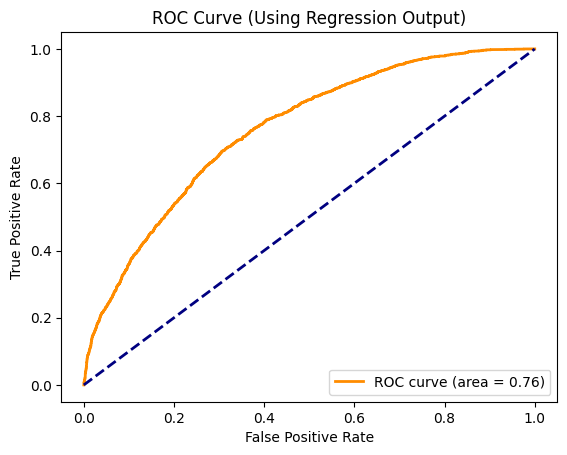

In [47]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {rc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Using Regression Output)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
a = [128, 64, 32, 8]
b = []
for num1 in a:
    num2_options = [num1, num1 // 2]
    if num1 != 128:
        num2_options.append(num1 * 2)
    for num2 in num2_options:
        num3_options = [num2, num2 // 2]
        if num2 != 128:
            num3_options.append(num2 * 2)
        for num3 in num3_options:
            num4_options = [num3, num3 // 2]
            if num3 != 128:
                num4_options.append(num2 * 2)
            for num4 in num4_options:
                b.append([num1, num2, num3, num4])
                
import sklearn.neural_network as sknn
arch = [8, 8, 4, 32, 2]
model = sknn.MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
model.fit(X_tab_train.cpu(), (y_train.cpu() > 0.3))
y_pred = model.predict(X_tab_test.cpu())
y_prob = model.predict_proba(X_tab_test.cpu())[:, 1]
print(arch)
performance_dict((y_test.cpu() > 0.3), y_pred, y_prob)